In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, RocCurveDisplay)
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

df.drop(columns=['customerID'], inplace=True)

print("Shape:", df.shape)
print("Nulls:", df.isnull().sum().sum())

Shape: (7043, 20)
Nulls: 0


In [3]:
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'Churn']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0, 
                           'Female': 1, 'Male': 0})

multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
              'OnlineBackup', 'DeviceProtection', 'TechSupport',
              'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print("Shape after encoding:", df.shape)
print(df.head())

Shape after encoding: (7043, 31)
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       1              0        1           0       1             0   
1       0              0        0           0      34             1   
2       0              0        0           0       2             1   
3       0              0        0           0      45             0   
4       1              0        0           0       2             1   

   PaperlessBilling  MonthlyCharges  TotalCharges  Churn  ...  \
0                 1           29.85         29.85      0  ...   
1                 0           56.95       1889.50      0  ...   
2                 1           53.85        108.15      1  ...   
3                 0           42.30       1840.75      0  ...   
4                 1           70.70        151.65      1  ...   

   TechSupport_Yes  StreamingTV_No internet service  StreamingTV_Yes  \
0            False                            False            False   
1    

In [4]:
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Churn rate in train:", y_train.mean().round(3))
print("Churn rate in test:", y_test.mean().round(3))

Train size: (5634, 30)
Test size: (1409, 30)
Churn rate in train: 0.265
Churn rate in test: 0.265


In [5]:
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [6]:
lr = LogisticRegression(class_weight='balanced', random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))
print("AUC-ROC:", roc_auc_score(y_test, y_prob_lr).round(4))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

AUC-ROC: 0.8416


In [8]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 2.7 MB/s eta 0:00:38
    --------------------------------------- 1.3/101.7 MB 3.4 MB/s eta 0:00:30
    --------------------------------------- 2.1/101.7 MB 3.3 MB/s eta 0:00:30
   - -------------------------------------- 2.6/101.7 MB 3.4 MB/s eta 0:00:30
   - -------------------------------------- 3.4/101.7 MB 3.3 MB/s eta 0:00:30
   - -------------------------------------- 3.7/101.7 MB 3.0 MB/s eta 0:00:33
   - -------------------------------------- 3.7/101.7 MB 3.0 MB/s eta 0:00:33
   - -------------------------------------- 3.7/101.7 MB 3.0 MB/s eta 0:00:33
   - -------------------------------------- 3.9/101.7 MB 2.0 MB/s eta 0:00:48
   - -------------------------------------- 3.9/101.7 MB 2.0 MB/s eta 0:00:48
   - -------------------------------------- 3.9/101.7 MB 2.0 MB/s eta 0:00:48
   - -------------------------------------- 3.9/101.7 MB 2.0 MB/s eta 0

In [9]:
from xgboost import XGBClassifier

xgb = XGBClassifier(scale_pos_weight=3, random_state=42, 
                    eval_metric='logloss', use_label_encoder=False)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print("AUC-ROC:", roc_auc_score(y_test, y_prob_xgb).round(4))

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.87      0.78      0.82      1035
           1       0.53      0.69      0.60       374

    accuracy                           0.75      1409
   macro avg       0.70      0.73      0.71      1409
weighted avg       0.78      0.75      0.76      1409

AUC-ROC: 0.8208


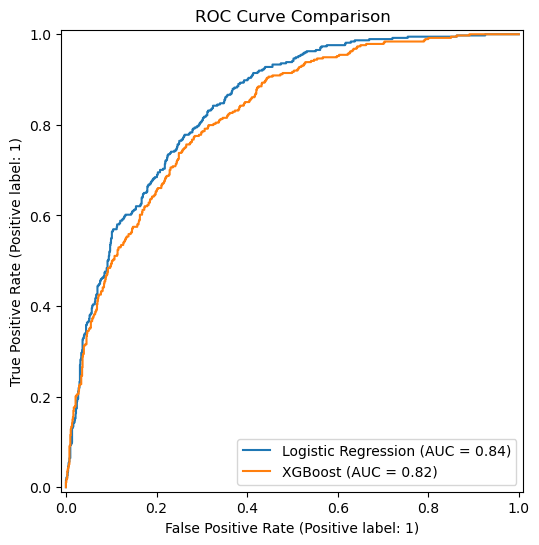

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_prob_lr, 
                                  name="Logistic Regression", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_prob_xgb, 
                                  name="XGBoost", ax=ax)
plt.title("ROC Curve Comparison")
plt.show()

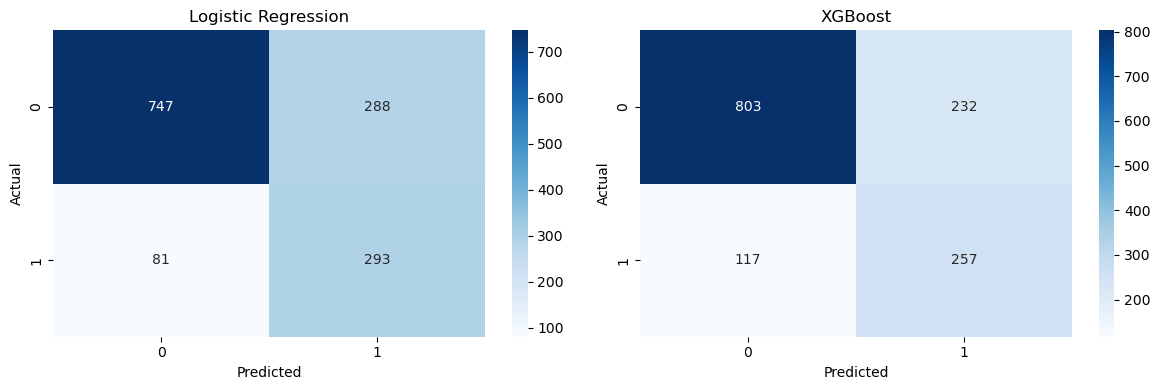

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, title in zip(axes, 
                             [y_pred_lr, y_pred_xgb],
                             ['Logistic Regression', 'XGBoost']):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()